# Task 4.2-4.3: Federated Learning Algorithm Comparison

This notebook contains the complete, self-contained implementation and comparison for FedAvg (Baseline), SCAFFOLD, and FedGH on the CIFAR-10 dataset with a non-IID data distribution.

In [1]:
# %% [markdown]
# ### Step 1: Imports and Global Configuration
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import copy
import pickle
from tqdm import tqdm

In [ ]:
# --- Single Source of Truth for Hyperparameters ---
NUM_CLIENTS = 10
NUM_ROUNDS = 50
LOCAL_EPOCHS = 5
BATCH_SIZE = 64
LOCAL_LR = 0.01
ALPHA_CHALLENGING = 0.1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FedGH-specific hyperparameters
GLOBAL_LRS_TO_TEST = [1.0]

# Create directories for results and figures
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print(f"Configuration Loaded. Using device: {DEVICE}")

Configuration Loaded. Using device: cuda


### Step 2: Shared Utilities (Model, Data Partitioning, Evaluation)

In [3]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(8 * 8 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 8 * 8 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

def dirichlet_partition_data(dataset, num_clients, alpha, batch_size):
    # This line is critical and now guaranteed to be correct
    num_classes = len(dataset.classes)
    class_indices = [np.where(np.array(dataset.targets) == i)[0] for i in range(num_classes)]
    client_indices = [[] for _ in range(num_clients)]
    for c_indices in class_indices:
        proportions = np.random.dirichlet([alpha] * num_clients)
        num_samples_for_class = (proportions * len(c_indices)).astype(int)
        rem = len(c_indices) - num_samples_for_class.sum()
        for i in range(rem):
            num_samples_for_class[i % num_clients] += 1
        start = 0
        for i in range(num_clients):
            end = start + num_samples_for_class[i]
            client_indices[i].extend(c_indices[start:end])
            start = end
            
    client_loaders = []
    for indices in client_indices:
        client_dataset = Subset(dataset, indices)
        loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
        client_loaders.append(loader)
        
    return client_loaders

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

# --- Global Data Loading ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
full_train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### Step 3: Algorithm Implementations

In [ ]:
# ---------------------------------------------------------------------------- #
#                                     FedAvg                                   #
# ---------------------------------------------------------------------------- #

def train_client_fedavg(model, data_loader, lr, local_epochs):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def run_fedavg_experiment(alpha, num_rounds, num_clients, local_epochs, batch_size, lr, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    result_filename = f'results/fedavg_alpha_{alpha}_b{batch_size}.pkl'
    os.makedirs(os.path.dirname(result_filename), exist_ok=True)

    if os.path.exists(result_filename):
        print(f"\n--- Loading existing FedAvg results from {result_filename} ---")
        with open(result_filename, 'rb') as f:
            return pickle.load(f)['accuracies']

    print(f"\n--- Running FedAvg Experiment (alpha={alpha}, batch_size={batch_size}) ---")
    client_loaders = dirichlet_partition_data(full_train_dataset, num_clients, alpha, batch_size)
    global_model = CIFAR_CNN().to(DEVICE)
    accuracies = []

    for round_num in range(num_rounds):
        start_time = time.time()
        local_updates = []
        client_iterator = tqdm(range(num_clients), desc=f"FedAvg Round {round_num+1}/{num_rounds}", leave=False)
        for client_idx in client_iterator:
            local_model = CIFAR_CNN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())
            updated_state = train_client_fedavg(local_model, client_loaders[client_idx], lr, local_epochs)
            local_updates.append(updated_state)
        
        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            global_state_dict[key] = torch.stack([s[key] for s in local_updates]).mean(dim=0)
        global_model.load_state_dict(global_state_dict)
        
        acc = evaluate_model(global_model, test_loader)
        accuracies.append(acc)
        round_time = time.time() - start_time
        print(f"FedAvg Round {round_num+1}/{num_rounds} | Accuracy: {acc:.2f}% | Time: {round_time:.2f}s")
    
    print(f"--- Saving FedAvg results to {result_filename} ---")
    with open(result_filename, 'wb') as f:
        pickle.dump({'accuracies': accuracies}, f)
    
    return accuracies

# ---------------------------------------------------------------------------- #
#                                   SCAFFOLD                                   #
# ---------------------------------------------------------------------------- #

def train_client_scaffold(model, data_loader, lr, local_epochs, c_global_dict, c_local_dict):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    initial_model_state = copy.deepcopy(model.state_dict())
    c_diff = {name: c_global_dict[name] - c_local_dict[name] for name in c_global_dict}

    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            for name, param in model.named_parameters():
                if param.grad is not None:
                    param.grad.data += c_diff[name].to(DEVICE)
            optimizer.step()
    
    final_model_state = model.state_dict()
    num_steps = len(data_loader) * local_epochs
    
    y_delta = {name: final_model_state[name].cpu() - initial_model_state[name].cpu() for name in final_model_state}
    c_plus_dict = copy.deepcopy(c_local_dict)
    c_delta_dict = {}
    with torch.no_grad():
        for name in c_global_dict:
            update_term = (initial_model_state[name].cpu() - final_model_state[name].cpu()) / (num_steps * lr)
            c_plus_dict[name] = c_local_dict[name] - c_global_dict[name] + update_term
            c_delta_dict[name] = c_plus_dict[name] - c_local_dict[name]
            
    return y_delta, c_delta_dict, c_plus_dict


def run_scaffold_experiment(alpha, num_rounds, num_clients, local_epochs, batch_size, lr, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    result_filename = f'results/scaffold_alpha_{alpha}_b{batch_size}.pkl'
    os.makedirs(os.path.dirname(result_filename), exist_ok=True)

    if os.path.exists(result_filename):
        print(f"\n--- Loading existing SCAFFOLD results from {result_filename} ---")
        with open(result_filename, 'rb') as f:
            return pickle.load(f)['accuracies']

    print(f"\n--- Running SCAFFOLD Experiment (alpha={alpha}, batch_size={batch_size}) ---")
    client_loaders = dirichlet_partition_data(full_train_dataset, num_clients, alpha, batch_size)
    global_model = CIFAR_CNN().to(DEVICE)
    c_global_dict = {name: torch.zeros_like(param).cpu() for name, param in global_model.named_parameters()}
    c_clients = {i: copy.deepcopy(c_global_dict) for i in range(num_clients)}
    accuracies = []
    S_clients = num_clients # Assuming full client participation

    for round_num in range(num_rounds):
        start_time = time.time()
        y_delta_cache, c_delta_cache = [], []
        client_iterator = tqdm(range(num_clients), desc=f"SCAFFOLD Round {round_num+1}/{num_rounds}", leave=False)
        for client_idx in client_iterator:
            local_model = CIFAR_CNN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())
            y_delta, c_delta, c_plus = train_client_scaffold(
                model=local_model, data_loader=client_loaders[client_idx],
                lr=lr, local_epochs=local_epochs,
                c_global_dict=c_global_dict, c_local_dict=c_clients[client_idx])
            y_delta_cache.append(y_delta)
            c_delta_cache.append(c_delta)
            c_clients[client_idx] = c_plus

        global_state_dict = global_model.state_dict()
        for name in global_state_dict:
            avg_y_delta = torch.stack([d[name] for d in y_delta_cache]).mean(dim=0)
            global_state_dict[name] += avg_y_delta.to(DEVICE)
        global_model.load_state_dict(global_state_dict)
        
        for name in c_global_dict:
            avg_c_delta = torch.stack([d[name] for d in c_delta_cache]).mean(dim=0)
            c_global_dict[name] += (S_clients / num_clients) * avg_c_delta

        acc = evaluate_model(global_model, test_loader)
        accuracies.append(acc)
        round_time = time.time() - start_time
        print(f"SCAFFOLD Round {round_num+1}/{num_rounds} | Accuracy: {acc:.2f}% | Time: {round_time:.2f}s")

    print(f"--- Saving SCAFFOLD results to {result_filename} ---")
    with open(result_filename, 'wb') as f:
        pickle.dump({'accuracies': accuracies}, f)
        
    return accuracies

# ---------------------------------------------------------------------------- #
#                                     FedGH                                    #
# ---------------------------------------------------------------------------- #

def train_client_and_get_delta(model, data_loader, lr, local_epochs):
    initial_state = copy.deepcopy(model.state_dict())
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    
    final_state = model.state_dict()
    model_delta = {name: final_state[name] - initial_state[name] for name in final_state}
    
    return model_delta

def harmonize_updates(model_deltas):
    num_clients = len(model_deltas)
    if num_clients <= 1:
        return model_deltas

    flat_deltas, shapes, param_keys = [], [], list(model_deltas[0].keys())

    for delta_dict in model_deltas:
        client_flat, current_shapes = [], []
        for key in param_keys:
            param = delta_dict[key]
            client_flat.append(param.view(-1))
            current_shapes.append(param.shape)
        flat_deltas.append(torch.cat(client_flat))
        shapes.append(current_shapes)
    
    original_flat_deltas = [d.clone() for d in flat_deltas]
    
    for i in range(num_clients):
        for j in range(i + 1, num_clients):
            g_i_orig, g_j_orig = original_flat_deltas[i], original_flat_deltas[j]
            dot_product = torch.dot(g_i_orig, g_j_orig)
            if dot_product < 0:
                norm_i_sq = torch.dot(g_i_orig, g_i_orig) + 1e-8
                norm_j_sq = torch.dot(g_j_orig, g_j_orig) + 1e-8
                flat_deltas[i] -= (dot_product / norm_j_sq) * g_j_orig
                flat_deltas[j] -= (dot_product / norm_i_sq) * g_i_orig

    harmonized_deltas = []
    for i, flat_delta in enumerate(flat_deltas):
        new_delta_dict, start = {}, 0
        client_shapes = shapes[i]
        for key, shape in zip(param_keys, client_shapes):
            num_elements = torch.prod(torch.tensor(shape)).item()
            param = flat_delta[start : start + num_elements].view(shape)
            new_delta_dict[key] = param
            start += num_elements
        harmonized_deltas.append(new_delta_dict)
        
    return harmonized_deltas

def run_fedgh_experiment(alpha, num_rounds, num_clients, local_epochs, batch_size, lr, global_lr, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    result_filename = f'results/fedgh_alpha_{alpha}_b{batch_size}_glr_{global_lr}.pkl'
    os.makedirs(os.path.dirname(result_filename), exist_ok=True)

    if os.path.exists(result_filename):
        print(f"\n--- Loading existing FedGH (glr={global_lr}) results from {result_filename} ---")
        with open(result_filename, 'rb') as f:
            return pickle.load(f)['accuracies']

    print(f"\n--- Running FedGH Experiment (alpha={alpha}, batch_size={batch_size}, global_lr={global_lr}) ---")
    client_loaders = dirichlet_partition_data(full_train_dataset, num_clients, alpha, batch_size)
    global_model = CIFAR_CNN().to(DEVICE)
    accuracies = []

    for round_num in range(num_rounds):
        start_time = time.time()
        model_deltas = []
        client_iterator = tqdm(range(num_clients), desc=f"FedGH (glr={global_lr}) Round {round_num+1}/{num_rounds}", leave=False)
        for client_idx in client_iterator:
            local_model = CIFAR_CNN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict())
            delta = train_client_and_get_delta(local_model, client_loaders[client_idx], lr, local_epochs)
            model_deltas.append(delta)

        harmonized_deltas = harmonize_updates(model_deltas)

        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            avg_delta = torch.stack([d[key] for d in harmonized_deltas]).mean(dim=0)
            global_state_dict[key] += global_lr * avg_delta
        global_model.load_state_dict(global_state_dict)
        
        acc = evaluate_model(global_model, test_loader)
        accuracies.append(acc)
        round_time = time.time() - start_time
        print(f"FedGH Round {round_num+1}/{num_rounds} | Accuracy: {acc:.2f}% | Time: {round_time:.2f}s")

    print(f"--- Saving FedGH (glr={global_lr}) results to {result_filename} ---")
    with open(result_filename, 'wb') as f:
        pickle.dump({'accuracies': accuracies}, f)
        
    return accuracies

### Step 4: Main Execution and Plotting

In [5]:
def plot_comparison(results_dict, alpha, batch_size):
    figure_filename = f'figures/comparison_alpha_{alpha}_b{batch_size}.png'
    os.makedirs(os.path.dirname(figure_filename), exist_ok=True)

    plt.figure(figsize=(12, 8))
    plt.style.use('seaborn-v0_8-whitegrid')

    styles = {
        'FedAvg': {'marker': 'x', 'linestyle': '--', 'zorder': 10},
        'SCAFFOLD': {'marker': 'o', 'linestyle': '-', 'markersize': 4},
        'FedGH': {'marker': 's', 'linestyle': ':', 'markersize': 4}
    }
    
    num_rounds = 0
    for name, accuracies in results_dict.items():
        if len(accuracies) > num_rounds:
            num_rounds = len(accuracies)
            
    rounds = range(1, num_rounds + 1)
    
    for name, accuracies in results_dict.items():
        base_algo_name = name.split(' ')[0]
        style = styles.get(base_algo_name, {'marker': 'd', 'linestyle': '-.'})
        plt.plot(rounds, accuracies, label=name, **style)

    plt.title(f'Algorithm Comparison on CIFAR-10 (α={alpha}, Batch Size={batch_size})', fontsize=16)
    plt.xlabel("Communication Round", fontsize=12)
    plt.ylabel("Global Test Accuracy (%)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.xticks(np.arange(0, num_rounds + 1, 5))
    plt.yticks(np.arange(0, 101, 10))
    plt.tight_layout()
    plt.savefig(figure_filename)
    print(f"\nFinal comparison plot saved to {figure_filename}")
    plt.show()

In [9]:
# --- Main Execution Block ---
if __name__ == '__main__':
    all_results = {}

    # --- Run FedAvg ---
    fedavg_accuracies = run_fedavg_experiment(
        alpha=ALPHA_CHALLENGING, num_rounds=NUM_ROUNDS, num_clients=NUM_CLIENTS,
        local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LOCAL_LR, seed=SEED)
    if fedavg_accuracies is not None:
        all_results['FedAvg'] = fedavg_accuracies


--- Loading existing FedAvg results from results/fedavg_alpha_0.1_b64.pkl ---


In [11]:
# --- Run SCAFFOLD ---
scaffold_accuracies = run_scaffold_experiment(
    alpha=ALPHA_CHALLENGING, num_rounds=NUM_ROUNDS, num_clients=NUM_CLIENTS,
    local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LOCAL_LR, seed=SEED)
if scaffold_accuracies is not None:
    all_results['SCAFFOLD'] = scaffold_accuracies


--- Loading existing SCAFFOLD results from results/scaffold_alpha_0.1_b64.pkl ---


In [13]:
# --- Run FedGH ---
fedgh_results = {}
for glr in GLOBAL_LRS_TO_TEST:
    accuracies = run_fedgh_experiment(
        alpha=ALPHA_CHALLENGING, num_rounds=NUM_ROUNDS, num_clients=NUM_CLIENTS,
        local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LOCAL_LR, 
        global_lr=glr, seed=SEED)
    if accuracies is not None:
            all_results[f'FedGH (glr={glr})'] = accuracies


--- Running FedGH Experiment (alpha=0.1, batch_size=64, global_lr=1.0) ---


FedGH Round 1/50 | Accuracy: 16.65% | Time: 22.57s


FedGH Round 2/50 | Accuracy: 26.07% | Time: 26.55s


FedGH Round 3/50 | Accuracy: 26.06% | Time: 27.94s


FedGH Round 4/50 | Accuracy: 29.42% | Time: 21.78s


...

FedGH Round 46/50 | Accuracy: 53.31% | Time: 22.32s


FedGH Round 47/50 | Accuracy: 59.62% | Time: 22.37s


FedGH Round 48/50 | Accuracy: 58.07% | Time: 22.02s


FedGH Round 49/50 | Accuracy: 56.11% | Time: 23.43s


FedGH Round 50/50 | Accuracy: 55.13% | Time: 22.19s
--- Saving FedGH (glr=1.0) results to results/fedgh_alpha_0.1_b64_glr_1.0.pkl ---



Plotting final comparison...

Final comparison plot saved to figures/comparison_alpha_0.1_b64.png


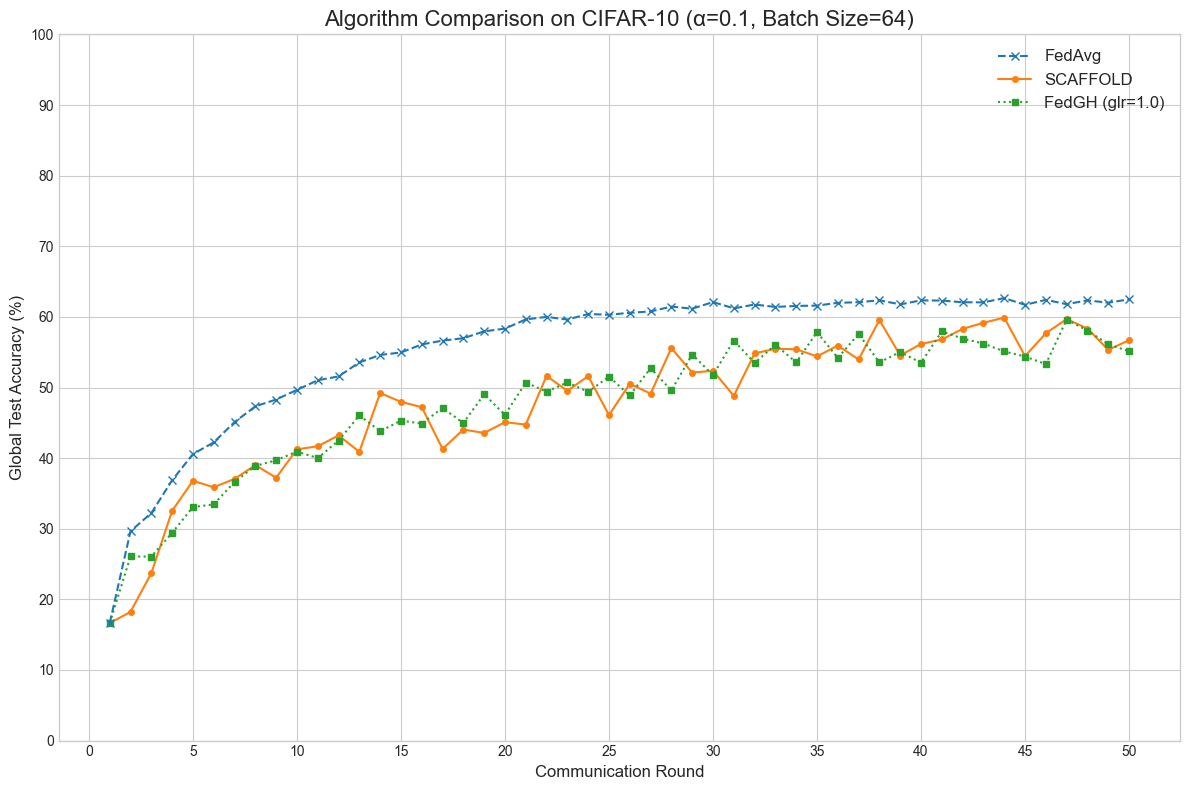

In [14]:
# --- Plot the results ---
if len(all_results) > 1:
    print("\nPlotting final comparison...")
    plot_comparison(all_results, alpha=ALPHA_CHALLENGING, batch_size=BATCH_SIZE)
else:
    print("\nSkipping plotting as fewer than two sets of results were available.")